In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("06-2024.csv")

In [3]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,53721402546,2024-06-01 09:06,Outbound,00:02:14,NaN,Oliver Martin
1,53721656442,2024-06-01 09:25,Outbound,00:00:30,NaN,Garrett Evans
2,53721997654,2024-06-01 10:00,Outbound,00:24:07,NaN,Keith Antonio
3,53722303027,2024-06-01 10:07,NaN,00:27:46,NaN,Sam Steindorf
4,53721762885,2024-06-01 10:16,Outbound,00:00:27,NaN,Garrett Evans


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7693 entries, 0 to 7692
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             7693 non-null   int64  
 1   Activity date         7693 non-null   object 
 2   Call direction        6316 non-null   object 
 3   Call duration         6606 non-null   object 
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  7481 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 360.7+ KB


In [5]:
df1 = df.drop(columns=['hs_call_outcome', 'Record ID'])

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7693 entries, 0 to 7692
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Activity date         7693 non-null   object
 1   Call direction        6316 non-null   object
 2   Call duration         6606 non-null   object
 3   Activity assigned to  7481 non-null   object
dtypes: object(4)
memory usage: 240.5+ KB


In [7]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7693 entries, 0 to 7692
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         7693 non-null   datetime64[ns]
 1   Call direction        6316 non-null   object        
 2   Call duration         6606 non-null   object        
 3   Activity assigned to  7481 non-null   object        
dtypes: datetime64[ns](1), object(3)
memory usage: 240.5+ KB


# Call Count per day

In [9]:
df2 = df1.copy()

In [10]:
df2['date'] = df2['Activity date'].dt.date

In [11]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2024-06-01 09:06:00,Outbound,00:02:14,Oliver Martin,2024-06-01
1,2024-06-01 09:25:00,Outbound,00:00:30,Garrett Evans,2024-06-01
2,2024-06-01 10:00:00,Outbound,00:24:07,Keith Antonio,2024-06-01
3,2024-06-01 10:07:00,NaN,00:27:46,Sam Steindorf,2024-06-01
4,2024-06-01 10:16:00,Outbound,00:00:27,Garrett Evans,2024-06-01


In [12]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns= {'Activity date': 'date'})
)

In [13]:
daily_calls.head()

,date,call_count
0,2024-06-01,48
1,2024-06-02,24
2,2024-06-03,375
3,2024-06-04,341
4,2024-06-05,338


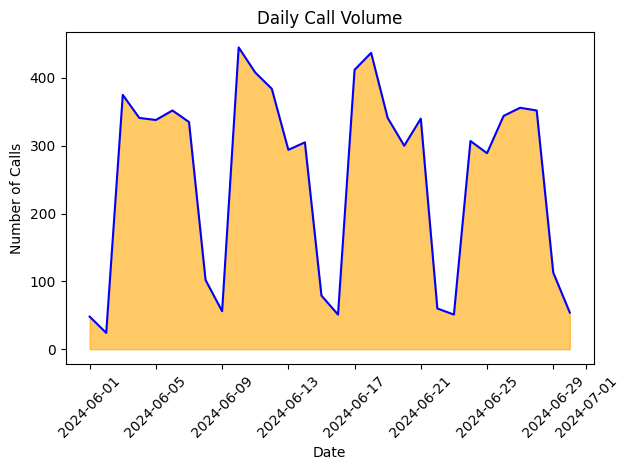

In [14]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'], color="blue")

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color ="orange", alpha=0.6)

plt.title('Daily Call Volume')
plt.xlabel('Date')
plt.ylabel('Number of Calls')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [15]:
df1['day'] = df1['Activity date'].dt.day_name()

In [16]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2024-06-01 09:06:00,Outbound,00:02:14,Oliver Martin,Saturday
1,2024-06-01 09:25:00,Outbound,00:00:30,Garrett Evans,Saturday
2,2024-06-01 10:00:00,Outbound,00:24:07,Keith Antonio,Saturday
3,2024-06-01 10:07:00,NaN,00:27:46,Sam Steindorf,Saturday
4,2024-06-01 10:16:00,Outbound,00:00:27,Garrett Evans,Saturday


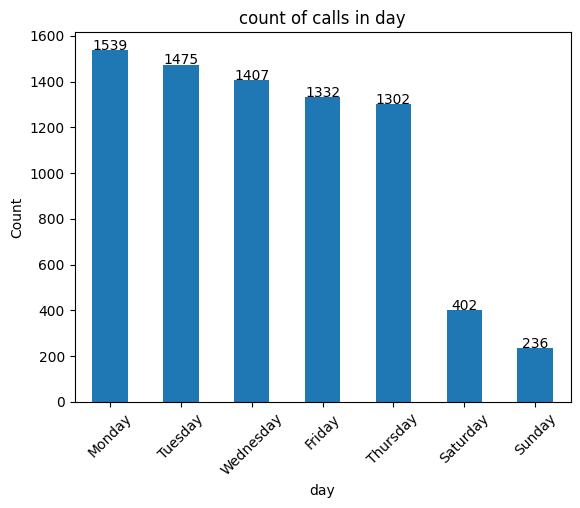

In [17]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

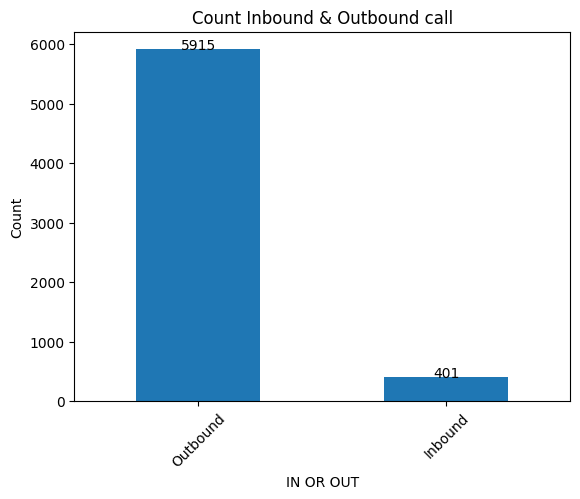

In [18]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel("IN OR OUT")
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [19]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

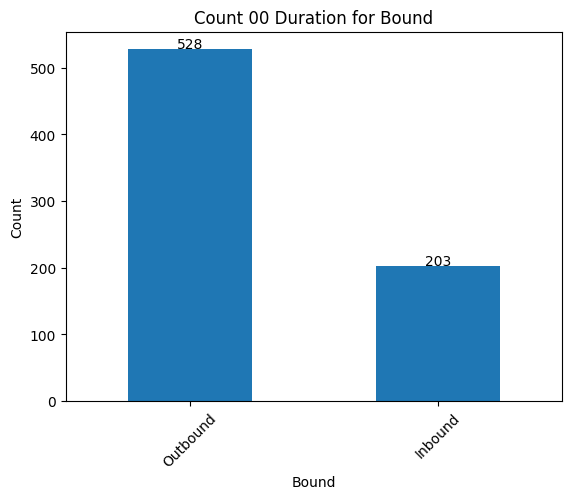

In [20]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [21]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
450,2024-06-04 09:05:00,Outbound,NaN,Sam Steindorf,Tuesday
490,2024-06-04 11:09:00,Outbound,NaN,Cameron Dudley,Tuesday
494,2024-06-04 11:14:00,Outbound,NaN,Cameron Dudley,Tuesday
521,2024-06-04 11:43:00,Outbound,NaN,Cameron Dudley,Tuesday
806,2024-06-05 10:09:00,Outbound,NaN,Cameron Dudley,Wednesday
1129,2024-06-06 09:21:00,Outbound,NaN,Sam Steindorf,Thursday
1144,2024-06-06 10:06:00,Outbound,NaN,David Valdez,Thursday
1321,2024-06-06 14:54:00,Inbound,NaN,Cameron Dudley,Thursday
1322,2024-06-06 14:57:00,Outbound,NaN,Cameron Dudley,Thursday
2017,2024-06-10 10:43:00,Outbound,NaN,Cameron Dudley,Monday


In [22]:
df4 = df1.copy()

In [23]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [24]:
(df4['Call duration'] == 0).sum()

731

In [25]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7693 entries, 0 to 7692
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         7693 non-null   datetime64[ns]
 1   Call direction        6316 non-null   object        
 2   Call duration         6606 non-null   float64       
 3   Activity assigned to  7481 non-null   object        
 4   day                   7693 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 300.6+ KB


In [26]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [27]:
df4 = df4.dropna(subset = ['Call direction'])

In [28]:
(df4['Call duration'] == 0).sum()

749

In [29]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6316 entries, 0 to 7692
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         6316 non-null   datetime64[ns]
 1   Call direction        6316 non-null   object        
 2   Call duration         6316 non-null   float64       
 3   Activity assigned to  6114 non-null   object        
 4   day                   6316 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 296.1+ KB


# Working Call Assigner

In [30]:
df1['Activity assigned to'].nunique()

20

In [31]:
df1['Activity assigned to'].unique()

array(['Oliver Martin', 'Garrett Evans', 'Keith Antonio', 'Sam Steindorf',
       'David Valdez', nan, 'Tyler Jury', 'Robin Stoehr',
       'Cameron Dudley', 'David Banister', 'Tanner Schunk', 'Paol Guzman',
       'Karen Parker', 'Terry Kim', 'Stephen Tarr', 'Bill Goodwin',
       'Juan Calo', 'Chrystel Manabat', 'Brittany Digiulio',
       'Adonis Baybayan', 'Henry Good'], dtype=object)

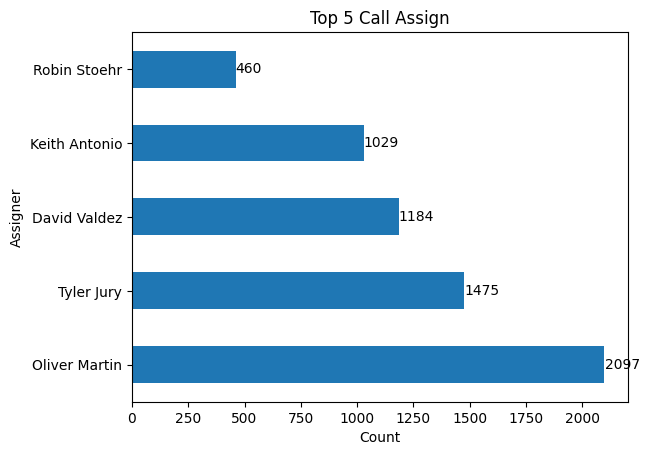

In [32]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# MAX CALL DURATION

In [76]:
df4['Call duration'].max()

98.55

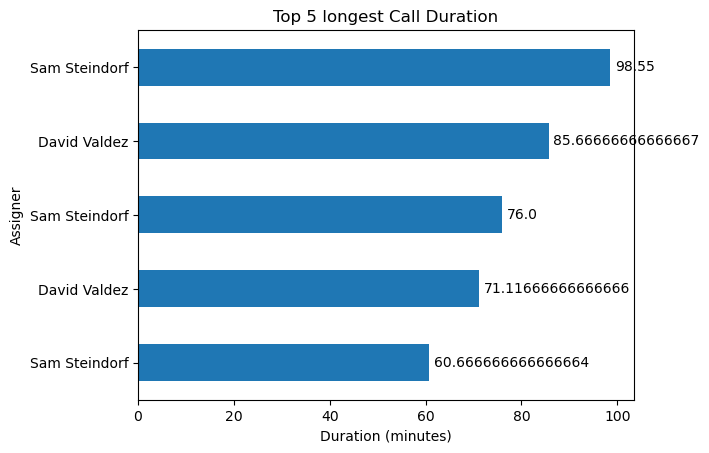

In [80]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [83]:
df3 = df1.copy()

In [85]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [87]:
df3['day'].unique()

<ArrowStringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 5, dtype: str

In [89]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

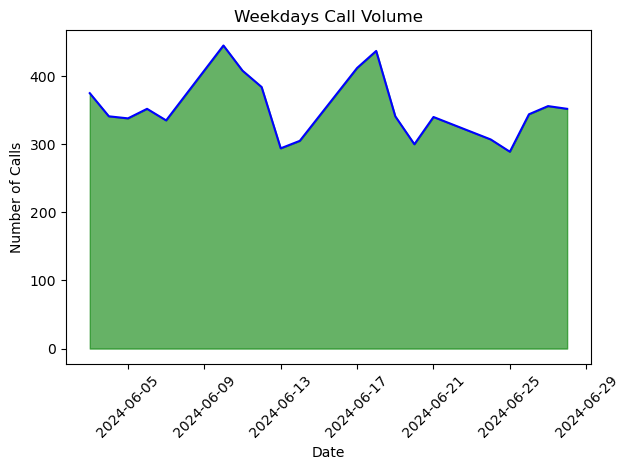

In [91]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'],week_day_calls['call_count'], color='green', alpha=0.6)

plt.title("Weekdays Call Volume")
plt.xlabel('Date')
plt.ylabel('Number of Calls')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [94]:
df5=df4.copy()

In [96]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [98]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2024-06-01 09:06:00,Outbound,2.233333,Oliver Martin,Saturday
1,2024-06-01 09:25:00,Outbound,0.500000,Garrett Evans,Saturday
2,2024-06-01 10:00:00,Outbound,24.116667,Keith Antonio,Saturday
4,2024-06-01 10:16:00,Outbound,0.450000,Garrett Evans,Saturday
5,2024-06-01 10:24:00,Outbound,0.550000,Keith Antonio,Saturday


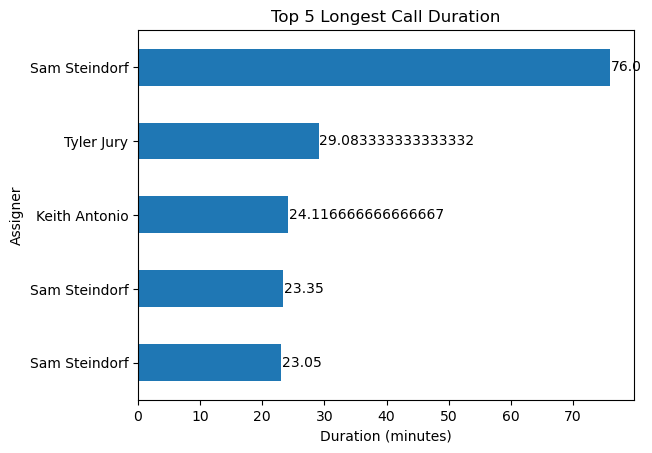

In [100]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

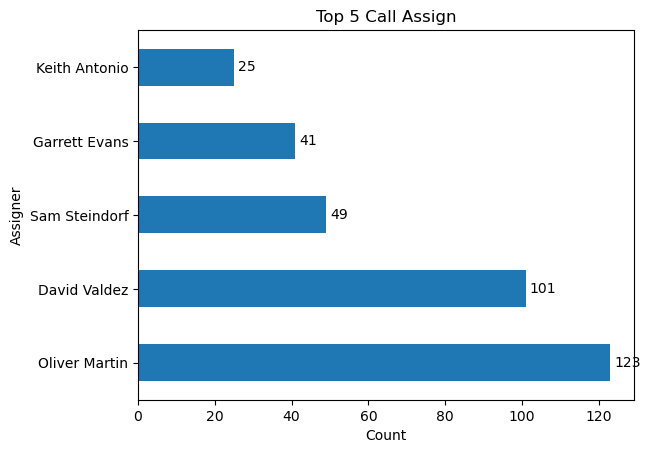

In [103]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Without Call Assigner Calls

In [106]:
df6 = df3.copy()

In [108]:
df6['month'] = df6['Activity date'].dt.month_name()

In [110]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

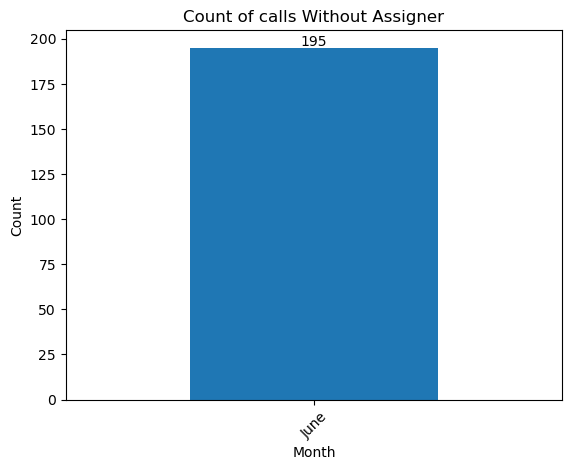

In [112]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call Date

In [115]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [117]:
top5 = daily_calls.sort_values(ascending=False).head(5)

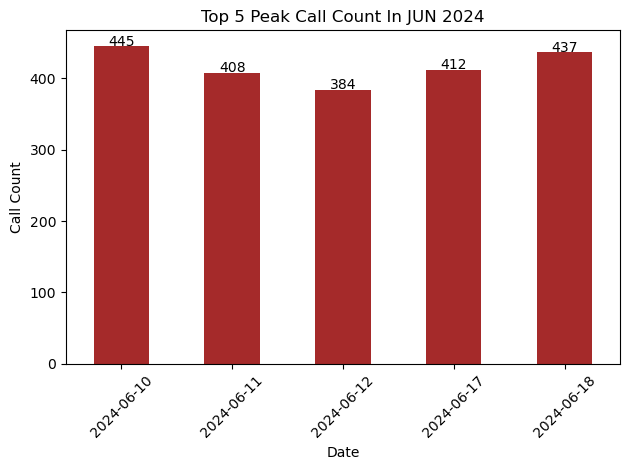

In [121]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In JUN 2024")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()